## Batched model tutorial
In this tutorial we demonstrate that for problems where more than one output is involved (constraints and objectives)
and
you are ok using only perfect samples (no NaNs in any output), a significant speedup can be achieved by using a
batched model. On GPU, this can get you 2-3x speedup.

In [1]:
import numpy as np
import time

import matplotlib.pyplot as plt
import pandas as pd
import threadpoolctl
import torch

from xopt import Xopt
from xopt.evaluator import Evaluator
from xopt.generators.bayesian import ExpectedImprovementGenerator
from xopt.generators.bayesian.models.standard import (
    BatchedModelConstructor,
    StandardModelConstructor,
)
from xopt.numerical_optimizer import LBFGSOptimizer
from xopt.resources.test_functions.rosenbrock import evaluate_rosenbrock

HAS_CUDA = False
step_size = 2
if torch.cuda.is_available():
    step_size = 20
    HAS_CUDA = True

torch.set_num_threads(1)
threadpoolctl.threadpool_limits(limits=1, user_api="blas")
threadpoolctl.threadpool_limits(limits=1, user_api="openmp")

vocs = {
    "variables": {f"x{i}": [-3, 3] for i in range(16)},
    "objectives": {"y": "MINIMIZE"},
    "constraints": {
        "c1": ["GREATER_THAN", 0.1],
        "c2": ["LESS_THAN", 3],
        "c3": ["GREATER_THAN", 0],
    },
}


def eval_f(input_dict):
    rosenbrock = False  # change to try another function
    d = {
        "y2": input_dict["x0"] + input_dict["x1"],
        "c1": input_dict["x2"] + input_dict["x3"],
        "c2": input_dict["x4"] + input_dict["x5"],
        "c3": input_dict["x0"],
    }
    if rosenbrock:
        d["y"] = evaluate_rosenbrock(input_dict)["y"]
    else:
        d["y"] = (
            np.sum(np.array([input_dict[f"x{i}"] ** 2 for i in range(16)]))
            + np.random.randn() * 0.01
        )
    return d

In [2]:
evaluator = Evaluator(function=eval_f)
generator = ExpectedImprovementGenerator(
    vocs=vocs,
    gp_constructor=StandardModelConstructor(train_method="adam"),
    numerical_optimizer=LBFGSOptimizer(n_restarts=5),
    use_cuda=HAS_CUDA,
)
X = Xopt(evaluator=evaluator, generator=generator)
generator_batched = ExpectedImprovementGenerator(
    vocs=vocs,
    gp_constructor=BatchedModelConstructor(train_method="adam"),
    numerical_optimizer=LBFGSOptimizer(n_restarts=5),
    use_cuda=HAS_CUDA,
)
X2 = Xopt(evaluator=evaluator, generator=generator_batched)

In [3]:
X.random_evaluate(20)
X2.random_evaluate(20)

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,...,x13,x14,x15,y2,c1,c2,c3,y,xopt_runtime,xopt_error
0,2.530359,-0.483607,2.977549,0.667897,1.883621,-1.178357,1.186676,-0.867537,2.663795,-1.257034,...,0.444137,-0.309948,1.031192,2.046752,3.645446,0.705264,2.530359,42.232873,0.000053,False
1,-2.537979,2.602105,-1.168087,0.902160,-0.168265,0.908810,0.279436,-2.778655,0.055714,0.788785,...,-1.667837,0.313590,2.560833,0.064126,-0.265926,0.740545,-2.537979,37.396118,0.000023,False
2,-0.128292,1.224136,-2.559847,2.023728,0.534145,2.793043,-0.438603,-2.724523,-0.733133,1.559070,...,1.879763,2.324478,-2.733275,1.095844,-0.536119,3.327188,-0.128292,51.272022,0.000020,False
3,0.892401,-0.168490,-0.533376,-1.438049,-2.601313,-2.774259,0.873881,-2.131834,1.273006,1.199718,...,-1.937481,0.286196,2.886149,0.723911,-1.971425,-5.375572,0.892401,44.820951,0.000020,False
4,1.266089,0.786721,1.900097,0.081276,-2.072954,1.682511,1.262512,0.802408,0.009078,-0.466982,...,-1.029193,2.122435,0.222470,2.052810,1.981373,-0.390442,1.266089,27.187168,0.000050,False
5,1.226494,-0.995514,-2.334508,-2.654147,0.866040,-1.521686,1.803557,-1.966229,0.304910,1.688301,...,-2.889754,-0.490360,-2.797282,0.230980,-4.988655,-0.655646,1.226494,56.559300,0.000019,False
6,1.866079,-0.131580,2.830581,-0.751016,-2.005187,-1.046025,-2.002879,0.557365,1.591521,-2.879903,...,1.892582,-0.424071,-2.922446,1.734499,2.079565,-3.051212,1.866079,48.863456,0.000031,False
7,2.737479,2.049004,2.867006,2.804292,-0.042398,-1.028832,2.963699,-1.027087,-1.593344,-1.231666,...,1.155536,2.494239,-2.119974,4.786483,5.671298,-1.071230,2.737479,67.464421,0.000019,False
8,-1.765841,0.707336,-1.879417,0.032684,1.962415,1.020363,-2.309685,-1.938998,1.681153,-2.000216,...,-1.821174,-0.213062,-0.809812,-1.058505,-1.846733,2.982778,-1.765841,37.530023,0.000020,False
9,1.241461,-0.422145,2.619224,1.488060,-1.540562,2.562674,0.879389,2.565030,2.230763,1.236514,...,2.383879,-1.378750,-0.974263,0.819316,4.107284,1.022113,1.241461,49.121261,0.000016,False


## Run the optimization
We run the optimizers side by side to compare speed. In the interest of saving time, we skip 10 points by
 sampling randomly between optimization steps.

In [4]:
history = []
for i in range(50):
    torch.cuda.empty_cache()
    X.random_evaluate(step_size)

    # sync data
    X2.data = X.data.copy()
    X2.generator.data = X.generator.data.copy()

    t1 = time.perf_counter()
    X.step()
    t2 = time.perf_counter()
    X2.step()
    t3 = time.perf_counter()
    if i % 10 == 0:
        print(f"Step {i}")
    history.append(
        {
            "n": len(X.data),
            "Standard training": X.generator.computation_time["training"].to_numpy()[
                -1
            ],  # t2-t1,
            "Standard acquisition": X.generator.computation_time[
                "acquisition_optimization"
            ].to_numpy()[-1],
            "Batched training": X2.generator.computation_time["training"].to_numpy()[
                -1
            ],  # t3-t2
            "Batched acquisition": X2.generator.computation_time[
                "acquisition_optimization"
            ].to_numpy()[-1],
        }
    )

Step 0


Step 10


Step 20


Step 30


Step 40


## Plot performance
Let's plot the timings.

Text(0.5, 1.0, 'Vars: 16, Objs: 1, Cons: 3, GPU: False')

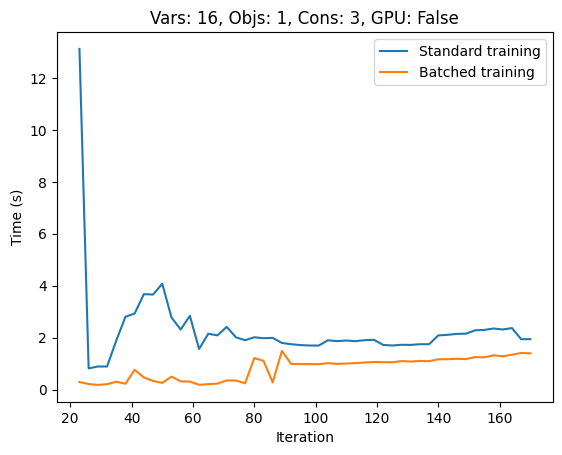

In [5]:
history_df = pd.DataFrame(history)
fig, ax = plt.subplots(1, 1)
ax.plot(history_df["n"], history_df["Standard training"], label="Standard training")
ax.plot(history_df["n"], history_df["Batched training"], label="Batched training")
ax.set_ylabel("Time (s)")
ax.set_xlabel("Iteration")
ax.legend()
ax.set_title(
    f"Vars: {len(vocs['variables'])}, Objs: {len(vocs['objectives'])}, Cons: {len(vocs['constraints'])}, GPU: {generator.use_cuda}"
)

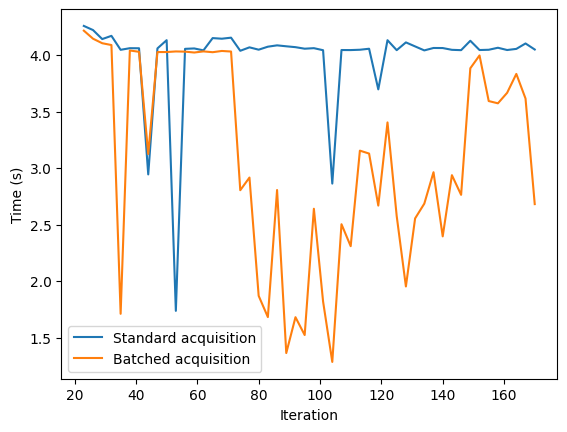

In [6]:
fig, ax = plt.subplots(1, 1)
ax.plot(
    history_df["n"],
    history_df["Standard acquisition"],
    label="Standard acquisition",
)
ax.plot(history_df["n"], history_df["Batched acquisition"], label="Batched acquisition")
ax.set_ylabel("Time (s)")
ax.set_xlabel("Iteration")
ax.legend()